In [1]:
import sys
sys.path.append("..")
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import json
from datetime import datetime
from datasets import load_from_disk

from torch.utils.data import DataLoader

In [2]:
# Загрузка модели, корневая папка проекта
from src.data import PROJECT_ROOT, RuleTakerDataset, create_minimal_pairs, compute_differential_stats, analyze_neuron_activations
from src.probing import run_probing_experiment, load_probing_results
from src.llm_upgrade import wrap_for_transformer_lens

In [3]:
sns.set_style("whitegrid")

In [4]:
CACHE_DIR = PROJECT_ROOT / "data/processed"
RESULTS_DIR = PROJECT_ROOT / "results/probing"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Эксперименты по зондированию на Pythia-1b

## Эксперимент 3: Pythia-1b + depth-0

In [5]:
# Параметры эксперимента
VARIANT = "depth-0"
MODEL_SIZE = "1b"
BASE_MODEL_NAME = "EleutherAI/pythia-1b-deduped"
ADAPTER_PATH = PROJECT_ROOT / "results/checkpoints/finetune/exp3/checkpoint-2200"
USE_SMALL = True
HOOK_NAME = "resid_post"
POOLING = "last"
BATCH_SIZE = 16

### Подготовка модели и данных

In [6]:
hooked_model, tokenizer = wrap_for_transformer_lens(
    base_model_name=BASE_MODEL_NAME,
    adapter_path=str(ADAPTER_PATH),
    device="cuda"
)
hooked_model.eval()

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model EleutherAI/pythia-1b-deduped into HookedTransformer


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (blocks): ModuleList(
    (0-15): 16 x TransformerBlock(
      (ln1): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
        (hook_rot_k): HookPoint()
        (hook_rot_q): HookPoint()
      )
      (mlp): MLP(
        (hook_pre): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out): HookPoint()
      (hook_mlp_out): HookPoint()
    

In [7]:
# Загружаем усеченную версию датасета
cache_suffix = f"{VARIANT}_small" if USE_SMALL else VARIANT
cache_path = CACHE_DIR / f"ruletaker_{cache_suffix}"
dataset = load_from_disk(str(cache_path))

In [8]:
# если выборка до 5000 наблюдений
tmp_tokens = tokenizer(list(dataset["train"]["text"]), padding=False, truncation=False)
lengths = [len(ids) for ids in tmp_tokens['input_ids']]
max_full = max(lengths)
max_p95 = int(np.percentile(lengths, 95))
print(f"95-й перцентиль: {max_p95} токенов (при макс длине {max_full})")

95-й перцентиль: 190 токенов (при макс длине 238)


In [9]:
# max_p95 = estimate_max_length(list(dataset["train"]["text"]), tokenizer, percentile=95, sample_size=500)

In [10]:
MAX_LENGTH = max_p95

In [11]:
train_dataset = RuleTakerDataset(dataset["train"], tokenizer, max_length=MAX_LENGTH)
dev_dataset = RuleTakerDataset(dataset["dev"], tokenizer, max_length=MAX_LENGTH)

In [12]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader   = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Метод probing classifiers

In [13]:
n_layers = hooked_model.cfg.n_layers
d_model = hooked_model.cfg.d_model

In [14]:
n_layers

16

In [15]:
torch.cuda.empty_cache()

In [16]:
# Кэшируем активации
results = run_probing_experiment(
    hooked_model, train_loader, dev_loader, n_layers,
    hook_name=HOOK_NAME, pooling=POOLING
)

Probing layers:  94%|█████████▍| 15/16 [19:03<01:19, 79.18s/it]c:\MyPythonProjects\mephi_diss\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Probing layers: 100%|██████████| 16/16 [20:23<00:00, 76.45s/it]


In [17]:
# Извлечение данных для графиков
train_accs = results["train_accs"]
dev_accs = results["dev_accs"]
train_means = [s["mean_abs"] for s in results["train_stats"]]
dev_means = [s["mean_abs"] for s in results["dev_stats"]]
train_stds = [s["std_abs"] for s in results["train_stats"]]
dev_stds = [s["std_abs"] for s in results["dev_stats"]]
train_sparsity = [s["sparsity"] for s in results["train_stats"]]
dev_sparsity = [s["sparsity"] for s in results["dev_stats"]]

In [18]:
# Визуализация результатов
best_layer = int(np.argmax(dev_accs))
best_train_acc = float(train_accs[best_layer])
best_dev_acc = float(dev_accs[best_layer])
print(f"Лучший слой: {best_layer} (0-based), Dev Accuracy: {best_dev_acc:.4f}")

Лучший слой: 14 (0-based), Dev Accuracy: 0.6060


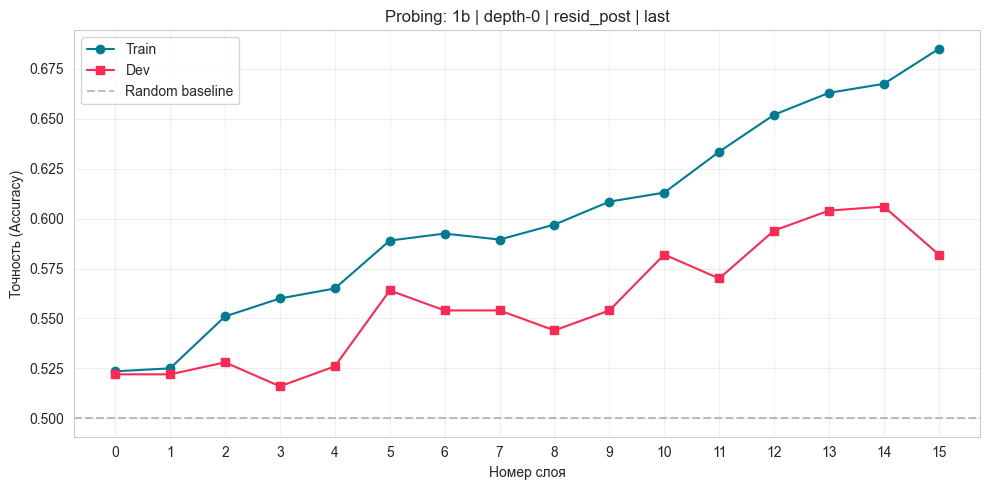

In [19]:
plt.figure(figsize=(10, 5))
x = np.arange(n_layers)
plt.plot(x, train_accs, marker="o", label="Train", color="xkcd:ocean")
plt.plot(x, dev_accs, marker="s", label="Dev", color="xkcd:red pink")
plt.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Random baseline")
plt.xlabel("Номер слоя")
plt.ylabel("Точность (Accuracy)")
plt.title(f"Probing: {MODEL_SIZE} | {VARIANT} | {HOOK_NAME} | {POOLING}")
plt.xticks(x)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

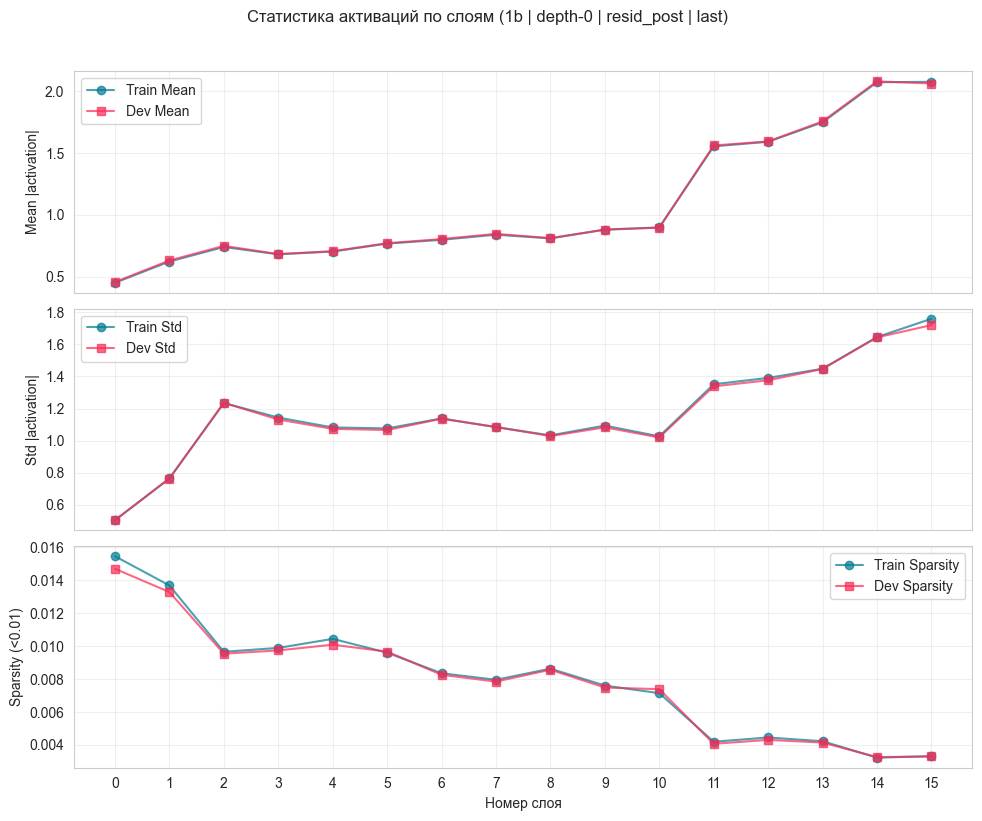

In [20]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax1.plot(x, train_means, marker="o", label="Train Mean", color="xkcd:ocean", alpha=0.7)
ax1.plot(x, dev_means, marker="s", label="Dev Mean", color="xkcd:red pink", alpha=0.7)
ax1.set_ylabel("Mean |activation|")
ax1.set_xticks(x)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(x, train_stds, marker="o", label="Train Std", color="xkcd:ocean", alpha=0.7)
ax2.plot(x, dev_stds, marker="s", label="Dev Std", color="xkcd:red pink", alpha=0.7)
ax2.set_ylabel("Std |activation|")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.plot(x, train_sparsity, marker="o", label="Train Sparsity", color="xkcd:ocean", alpha=0.7)
ax3.plot(x, dev_sparsity, marker="s", label="Dev Sparsity", color="xkcd:red pink", alpha=0.7)
ax3.set_ylabel("Sparsity (<0.01)")
ax3.set_xlabel("Номер слоя")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.suptitle(f"Статистика активаций по слоям ({MODEL_SIZE} | {VARIANT} | {HOOK_NAME} | {POOLING})", y=1.02)
plt.tight_layout()
plt.show()

In [16]:
# Сохранение метрик в JSON
fname = f"probe_{MODEL_SIZE}(qLoRA)_{VARIANT}_{HOOK_NAME}_{POOLING}.json"
fpath = RESULTS_DIR / fname

In [22]:
metrics = {
    "variant": VARIANT,
    "model_size": MODEL_SIZE,
    "hook_name": HOOK_NAME,
    "pooling": POOLING,
    "best_layer": best_layer,
    "best_dev_acc": float(best_dev_acc),
    "train_accs": [float(a) for a in train_accs],
    "dev_accs": [float(a) for a in dev_accs]
}

# Исходные условия эксперимента
metadata = {
    "experiment_type": "probing_layer_selection",
    "timestamp": datetime.now().isoformat(),
    "variant": VARIANT,
    "model_size": MODEL_SIZE,
    "hook_name": HOOK_NAME,
    "pooling": POOLING,
    "batch_size": BATCH_SIZE,
    "max_length": MAX_LENGTH
}

# Основной результат
summary = {
    "best_layer": best_layer,
    "best_train_acc": best_train_acc,
    "best_dev_acc": best_dev_acc,
    "n_layers": len(results["layers"])
}

# Свод
full_data = {
    "metadata": metadata,
    "summary": summary,
    "layers": results["layers"],
    "train_accs": [float(x) for x in results["train_accs"]],
    "dev_accs": [float(x) for x in results["dev_accs"]],
    "train_stats": results["train_stats"],
    "dev_stats": results["dev_stats"]
}

with open(fpath, "w", encoding="utf-8") as f:
    json.dump(full_data, f, indent=2, ensure_ascii=False)
print(f"Результаты сохранены: {fpath}")

Результаты сохранены: C:\MyPythonProjects\mephi_diss\results\probing\probe_1b(qLoRA)_depth-0_resid_post_last.json


### Проверка токенизации

In [17]:
# Список ключевых слов для проверки
logic_keywords = ["if", "then", "and", "or", "not", "implies", "is", "are", "all", "some", "no"]

In [18]:
# Возьмём несколько примеров из датасета (первые 3 из train)
sample_texts = list(dataset["train"]["text"])[:3]

In [19]:
for i, text in enumerate(sample_texts):
    print(f"Пример {i+1}:\n{text[:300]}...\n")  # первые 300 символов
    tokens = tokenizer.tokenize(text)
    print(f"Токены (первые 50): {tokens[:50]}\n")

    # Проверка каждого ключевого слова
    print("Наличие ключевых слов в тексте и токенах:")
    for kw in logic_keywords:
        in_text = kw in text.lower()
        # ищем токен, совпадающий с kw (без учёта регистра)
        in_tokens = any(tok.lstrip("Ġ").lower() == kw for tok in tokens)
        print(f"  '{kw}': в тексте={in_text}, в токенах={in_tokens}")
    print("-" * 80)

Пример 1:
Anne is blue. Anne is rough. Anne is young. All young people are cold. If someone is rough and nice then they are green. Rough people are young. If Anne is green then Anne is blue. If someone is rough and furry then they are blue. Cold people are rough. Anne is rough....

Токены (первые 50): ['Anne', 'Ġis', 'Ġblue', '.', 'ĠAnne', 'Ġis', 'Ġrough', '.', 'ĠAnne', 'Ġis', 'Ġyoung', '.', 'ĠAll', 'Ġyoung', 'Ġpeople', 'Ġare', 'Ġcold', '.', 'ĠIf', 'Ġsomeone', 'Ġis', 'Ġrough', 'Ġand', 'Ġnice', 'Ġthen', 'Ġthey', 'Ġare', 'Ġgreen', '.', 'ĠRough', 'Ġpeople', 'Ġare', 'Ġyoung', '.', 'ĠIf', 'ĠAnne', 'Ġis', 'Ġgreen', 'Ġthen', 'ĠAnne', 'Ġis', 'Ġblue', '.', 'ĠIf', 'Ġsomeone', 'Ġis', 'Ġrough', 'Ġand', 'Ġfur', 'ry']

Наличие ключевых слов в тексте и токенах:
  'if': в тексте=True, в токенах=True
  'then': в тексте=True, в токенах=True
  'and': в тексте=True, в токенах=True
  'or': в тексте=False, в токенах=False
  'not': в тексте=False, в токенах=False
  'implies': в тексте=False, в токенах=False


In [20]:
# Токенизация самих ключевых слов как отдельных строк
for kw in logic_keywords:
    tokens_kw = tokenizer.tokenize(kw)
    is_single = len(tokens_kw) == 1
    print(f"'{kw}' -> {tokens_kw} (цельный токен: {is_single})")

'if' -> ['if'] (цельный токен: True)
'then' -> ['then'] (цельный токен: True)
'and' -> ['and'] (цельный токен: True)
'or' -> ['or'] (цельный токен: True)
'not' -> ['not'] (цельный токен: True)
'implies' -> ['impl', 'ies'] (цельный токен: False)
'is' -> ['is'] (цельный токен: True)
'are' -> ['are'] (цельный токен: True)
'all' -> ['all'] (цельный токен: True)
'some' -> ['some'] (цельный токен: True)
'no' -> ['no'] (цельный токен: True)


### Разностный анализ активаций

In [21]:
data = load_probing_results(MODEL_SIZE, VARIANT, HOOK_NAME, POOLING)

In [22]:
data

{'metadata': {'experiment_type': 'probing_layer_selection',
  'timestamp': '2026-04-05T19:19:11.917273',
  'variant': 'depth-0',
  'model_size': '1b',
  'hook_name': 'resid_post',
  'pooling': 'last',
  'batch_size': 16,
  'max_length': 191},
 'summary': {'best_layer': 11,
  'best_train_acc': 0.6045,
  'best_dev_acc': 0.568,
  'n_layers': 16},
 'layers': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 'train_accs': [0.525,
  0.524,
  0.541,
  0.5525,
  0.549,
  0.5625,
  0.5625,
  0.5855,
  0.5915,
  0.598,
  0.594,
  0.6045,
  0.611,
  0.6085,
  0.6205,
  0.6235],
 'dev_accs': [0.52,
  0.52,
  0.518,
  0.522,
  0.522,
  0.542,
  0.532,
  0.546,
  0.544,
  0.55,
  0.56,
  0.568,
  0.56,
  0.538,
  0.556,
  0.556],
 'train_stats': [{'mean_abs': 0.44878560304641724,
   'std_abs': 0.5060600638389587,
   'max_abs': 19.828125,
   'min_abs': 0.0,
   'sparsity': 0.012840576171875,
   'mean_by_neuron': 0.14250847697257996,
   'condition_number': inf,
   'effective_rank': 1.0,
   'max_

In [23]:
DIFF_LAYER = data["summary"]["best_layer"]

In [24]:
pairs = create_minimal_pairs(variant=VARIANT, n_pairs=30)

In [25]:
diff_stats = compute_differential_stats(
    hooked_model, tokenizer, pairs,
    layer_idx=DIFF_LAYER,
    hook_name=HOOK_NAME,
    pooling=POOLING,
    max_length=data["metadata"]["max_length"]   # или из MAX_LENGTH
)

In [26]:
print(f"Средняя абсолютная разница активаций: {diff_stats['mean_abs_diff']:.4f}")
print(f"Стандартное отклонение разницы: {diff_stats['std_diff']:.4f}")

Средняя абсолютная разница активаций: 0.0533
Стандартное отклонение разницы: 0.1625


In [27]:
neuron_sens = diff_stats['neuron_sensitivity']
top_neurons = np.argsort(neuron_sens)[-100:][::-1]
print("Топ-100 нейронов с наибольшей средней разницей:")
for i, n in enumerate(top_neurons):
    print(f"  Нейрон {n}: {neuron_sens[n]:.4f}")

Топ-100 нейронов с наибольшей средней разницей:
  Нейрон 1668: 0.4146
  Нейрон 232: 0.3917
  Нейрон 1638: 0.2896
  Нейрон 1467: 0.2786
  Нейрон 1429: 0.1823
  Нейрон 490: 0.1500
  Нейрон 1383: 0.1297
  Нейрон 1560: 0.1278
  Нейрон 1523: 0.1273
  Нейрон 1855: 0.1270
  Нейрон 1487: 0.1240
  Нейрон 1878: 0.1206
  Нейрон 1671: 0.1137
  Нейрон 1028: 0.1135
  Нейрон 873: 0.1120
  Нейрон 1866: 0.1117
  Нейрон 788: 0.1111
  Нейрон 1680: 0.1107
  Нейрон 416: 0.1091
  Нейрон 685: 0.1078
  Нейрон 1280: 0.1076
  Нейрон 29: 0.1074
  Нейрон 1616: 0.1073
  Нейрон 1371: 0.1070
  Нейрон 695: 0.1057
  Нейрон 1927: 0.1057
  Нейрон 712: 0.1052
  Нейрон 523: 0.1052
  Нейрон 198: 0.1047
  Нейрон 1235: 0.1042
  Нейрон 38: 0.1042
  Нейрон 1637: 0.1040
  Нейрон 502: 0.1030
  Нейрон 1541: 0.1027
  Нейрон 1286: 0.1026
  Нейрон 862: 0.1005
  Нейрон 327: 0.1005
  Нейрон 1405: 0.1004
  Нейрон 461: 0.1000
  Нейрон 1704: 0.1000
  Нейрон 1313: 0.0999
  Нейрон 919: 0.0992
  Нейрон 1384: 0.0992
  Нейрон 1520: 0.0988
  Н

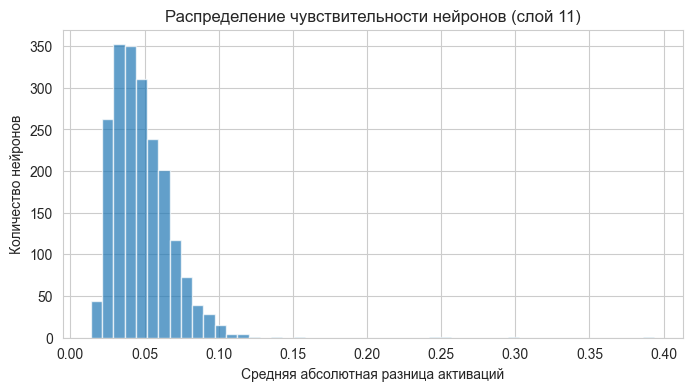

In [30]:
# Гистограмма чувствительности нейронов
plt.figure(figsize=(8,4))
plt.hist(neuron_sens, bins=50, alpha=0.7)
plt.xlabel("Средняя абсолютная разница активаций")
plt.ylabel("Количество нейронов")
plt.title(f"Распределение чувствительности нейронов (слой {DIFF_LAYER})")
plt.grid(True)
plt.show()

In [29]:
# Добавляем результаты разностного анализа в файл json с результатами пробинга
diff_stats["neuron_sensitivity"] = diff_stats["neuron_sensitivity"].tolist()
data["diff_stats"] = diff_stats
with open(fpath, "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2, ensure_ascii=False)
    print(f"Результаты разностного анализа добавлены в {fpath}")

Результаты разностного анализа добавлены в C:\MyPythonProjects\mephi_diss\results\probing\probe_1b(qLoRA)_depth-0_resid_post_last.json


In [38]:
top_texts, top_tokens = analyze_neuron_activations(
    hooked_model, tokenizer,
    layer_idx=14, neuron_idx=1668,
    texts=list(dataset["train"]["text"])[:200],
    top_k_examples=10,
    top_k_tokens=30
)

In [39]:
print("Топ-10 примеров для нейрона 1668:")
for text, act in top_texts:
    print(f"  [{act:.3f}] {text}")

Топ-10 примеров для нейрона 1668:
  [18.500] The bald eagle eats the rabbit. The bald eagle is nice. The bald eagle sees the dog. The bald eagle visits the dog. The dog eats the rabbit. The dog is nice. The dog is red. The dog is round. The dog sees the rabbit. The dog visits the bald eagle. The dog visits the rabbit. The rabbit eats the dog. The rabbit is not red. The rabbit sees the bald eagle. The rabbit visits the dog. If something is blue then it is nice. If something visits the rabbit then it is round. The bald eagle does not eat the rabbit.
  [15.125] Bob is red. Dave is white. Fiona is red. Fiona is white. Gary is furry. Gary is not green. Gary is red. All big people are furry. Young, white people are not green. If Gary is round then Gary is not red. If someone is white and not green then they are furry. If someone is young then they are white. If Bob is young then Bob is red. If someone is green and not white then they are big. If someone is not round and not white then they a

In [40]:
print("Топ-30 токенов для нейрона 1668:")
for token, score in top_tokens:
    print(f"{token.strip()}: {score:+.3f}")

Топ-30 токенов для нейрона 1668:
rin: +75.500
The: +70.797
Bob: +69.500
Gary: +69.000
Dave: +67.000
Charlie: +66.500
Anne: +62.462
F: +59.625
E: +56.500
red: +45.363
nice: +44.831
cold: +43.904
green: +43.311
rough: +42.780
likes: +42.756
big: +42.696
smart: +42.131
round: +41.851
need: +41.283
white: +40.657
quiet: +40.090
like: +39.929
needs: +39.782
visits: +39.632
blue: +39.534
kind: +38.916
see: +38.605
sees: +37.734
visit: +37.295
young: +36.068


In [35]:
top_texts, top_tokens = analyze_neuron_activations(
    hooked_model, tokenizer,
    layer_idx=14, neuron_idx=232,
    texts=list(dataset["train"]["text"])[:200],
    top_k_examples=10,
    top_k_tokens=30
)

In [36]:
print("Топ-10 примеров для нейрона 232:")
for text, act in top_texts:
    print(f"  [{act:.3f}] {text}")

Топ-10 примеров для нейрона 232:
  [11.250] The squirrel is blue. The squirrel is cold. The squirrel is young. If the squirrel is round then the squirrel is big. The squirrel is not big.
  [9.688] The cat eats the cow. The cat is cold. The cat is rough. The cat does not visit the rabbit. The cow eats the cat. The cow is big. The rabbit is nice. The rabbit does not like the cat. The rabbit likes the cow. The rabbit does not visit the cat. If something is cold and it likes the cow then the cow is not big. If something is nice and rough then it visits the cat. If the rabbit is nice then the rabbit eats the cat. If something visits the cow and it is rough then the cow likes the cat. If the cow eats the rabbit then the rabbit is nice. If something is big and it visits the cat then it eats the cow. If something does not eat the rabbit and it does not eat the cow then it visits the cow. If something visits the cat and the cat does not eat the cow then it is not cold. The cat likes the cat.
  

In [37]:
print("Топ-30 токенов для нейрона 232:")
for token, score in top_tokens:
    print(f"{token.strip()}: {score:+.3f}")

Топ-30 токенов для нейрона 232:
E: +536.000
Dave: +466.909
Anne: +460.000
Charlie: +427.000
F: +426.000
Bob: +414.000
The: +410.759
Gary: +364.000
rin: +13.750
.: +9.954
bear: +8.579
someone: +8.196
cat: +8.049
round: +7.951
green: +7.875
cold: +7.867
big: +7.488
If: +7.433
needs: +7.340
young: +7.257
Bob: +6.955
nice: +6.949
eagle: +6.920
Dave: +6.854
tiger: +6.836
like: +6.832
need: +6.831
red: +6.802
blue: +6.776
rabbit: +6.734
